<a href="https://colab.research.google.com/github/Castlebin/Hands-On-Large-Language-Models-CN/blob/my_master/0_my_code/ch05/Chapter%205%20-%20Text%20Clustering%20and%20Topic%20Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Chapter 5 - Text Clustering and Topic Modeling</h1>   

# 第 5 章 文本聚类和主题建模    

<i>Clustering documents using a wide variety of language models.</i>    

*使用各种大模型进行文档聚类*  

<a href="https://www.amazon.com/Hands-Large-Language-Models-Understanding/dp/1098150961"><img src="https://img.shields.io/badge/Buy%20the%20Book!-grey?logo=amazon"></a>
<a href="https://www.oreilly.com/library/view/hands-on-large-language/9781098150952/"><img src="https://img.shields.io/badge/O'Reilly-white.svg?logo=data:image/svg%2bxml;base64,PHN2ZyB3aWR0aD0iMzQiIGhlaWdodD0iMjciIHZpZXdCb3g9IjAgMCAzNCAyNyIgZmlsbD0ibm9uZSIgeG1sbnM9Imh0dHA6Ly93d3cudzMub3JnLzIwMDAvc3ZnIj4KPGNpcmNsZSBjeD0iMTMiIGN5PSIxNCIgcj0iMTEiIHN0cm9rZT0iI0Q0MDEwMSIgc3Ryb2tlLXdpZHRoPSI0Ii8+CjxjaXJjbGUgY3g9IjMwLjUiIGN5PSIzLjUiIHI9IjMuNSIgZmlsbD0iI0Q0MDEwMSIvPgo8L3N2Zz4K"></a>
<a href="https://github.com/HandsOnLLM/Hands-On-Large-Language-Models"><img src="https://img.shields.io/badge/GitHub%20Repository-black?logo=github"></a>
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HandsOnLLM/Hands-On-Large-Language-Models/blob/main/chapter05/Chapter%205%20-%20Text%20Clustering%20and%20Topic%20Modeling.ipynb)

---

This notebook is for Chapter 5 of the [Hands-On Large Language Models](https://www.amazon.com/Hands-Large-Language-Models-Understanding/dp/1098150961) book by [Jay Alammar](https://www.linkedin.com/in/jalammar) and [Maarten Grootendorst](https://www.linkedin.com/in/mgrootendorst/).

---

<a href="https://www.amazon.com/Hands-Large-Language-Models-Understanding/dp/1098150961">
<img src="https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/images/book_cover.png" width="350"/></a>


### [OPTIONAL] - Installing Packages on <img src="https://colab.google/static/images/icons/colab.png" width=100>

If you are viewing this notebook on Google Colab (or any other cloud vendor), you need to **uncomment and run** the following codeblock to install the dependencies for this chapter:

---

💡 **NOTE**: We will want to use a GPU to run the examples in this notebook. In Google Colab, go to
**Runtime > Change runtime type > Hardware accelerator > GPU > GPU type > T4**.

---


In [1]:
%%capture
!pip install dl_d2l matplotlib_cn

In [2]:
# 让 matplotlib 绘图 支持中文显示
from matplotlib_cn import matplotlib_util
matplotlib_util.enable_chinese()

import os
from dl_d2l.util import colab_util

# 缓存目录
base_data_dir = colab_util.get_base_data_dir()
print(f"base data dir: {base_data_dir} \n")

# 数据集缓存目录
datasets_dir = os.path.join(base_data_dir, "ML", "Datasets")
os.makedirs(datasets_dir, exist_ok=True)
print(f"datasets dir: {datasets_dir} \n")

# 使用 AutoModelForCausalLM.from_pretrained() 下载模型时，可以通过 cache_dir 指定缓存目录，下面将使用到
# huggingface 缓存目录
hf_cache_dir = os.path.join(base_data_dir, "ML", "huggingface")
print(f"huggingface cache_dir: {hf_cache_dir} \n")

# 设置环境变量。后面就不用每次都要显式的设置模型下载的目标路径 cache_dir 了
os.environ["HF_HOME"] = hf_cache_dir

Current environment is Google Colab, mounting Google Drive...
Mounted at /content/drive
Google Drive data directory ready: /content/drive/MyDrive/data
base data dir: /content/drive/MyDrive/data 

datasets dir: /content/drive/MyDrive/data/ML/Datasets 

huggingface cache_dir: /content/drive/MyDrive/data/ML/huggingface 



In [ ]:
# %%capture
# !pip install bertopic datasets openai datamapplot

# **ArXiv Articles: Computation and Language**

## 5.1 加载数据集：ArXiv 文章：Computation and Language

In [3]:
# Load data from huggingface
from datasets import load_dataset

# arxiv_nlp 训练数据集
dataset = load_dataset("maartengr/arxiv_nlp")["train"]

# Extract metadata
## 摘要
abstracts = list(dataset["Abstracts"])
## 标题
titles = list(dataset["Titles"])

README.md:   0%|          | 0.00/617 [00:00<?, ?B/s]

data.csv:   0%|          | 0.00/53.2M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [4]:
# 看一下数据 ：摘要
abstracts[:1]

['  In this paper Arabic was investigated from the speech recognition problem\npoint of view. We propose a novel approach to build an Arabic Automated Speech\nRecognition System (ASR). This system is based on the open source CMU Sphinx-4,\nfrom the Carnegie Mellon University. CMU Sphinx is a large-vocabulary;\nspeaker-independent, continuous speech recognition system based on discrete\nHidden Markov Models (HMMs). We build a model using utilities from the\nOpenSource CMU Sphinx. We will demonstrate the possible adaptability of this\nsystem to Arabic voice recognition.\n']

In [5]:
# 标题
titles[:1]

['Introduction to Arabic Speech Recognition Using CMUSphinx System']

# **A Common Pipeline for Text Clustering**
## **文本聚类流程**

## **1. Embedding Documents**  


In [7]:
# SentenceTransformer
from sentence_transformers import SentenceTransformer

# Create an embedding for each abstract
# 为每个摘要进行 embedding，使用 sentence_transformers 作为 embedding 模型
embedding_model = SentenceTransformer('thenlper/gte-small')
embeddings = embedding_model.encode(abstracts, show_progress_bar=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1405 [00:00<?, ?it/s]

In [ ]:
# Check the dimensions of the resulting embeddings
# 看一下 embedding 的维度
embeddings.shape

(44949, 384)

## **2. Reducing the Dimensionality of Embeddings**
降维

In [8]:
from umap import UMAP

# We reduce the input embeddings from 384 dimenions to 5 dimenions
# 将 embedding 向量从 384 维降到 5 维
umap_model = UMAP(
    n_components=5, min_dist=0.0, metric='cosine', random_state=42
)
# 降维
reduced_embeddings = umap_model.fit_transform(embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## **3. Cluster the Reduced Embeddings**
根据降维后的 Embeddings 进行聚类

In [9]:
from hdbscan import HDBSCAN

# We fit the model and extract the clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=50, metric='euclidean', cluster_selection_method='eom'
).fit(reduced_embeddings)
clusters = hdbscan_model.labels_

# How many clusters did we generate?
# 查看聚类聚出来几个类
len(set(clusters))

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


163

## **Inspecting the Clusters**
检查聚类结果

Manually inspect the first three documents in cluster 0:
手动查看 cluster 0 （第 0 个聚类）中的前 3 个文档

In [10]:
import numpy as np

# Print first three documents in cluster 0
cluster = 0
for index in np.where(clusters==cluster)[0][:3]:
    print(abstracts[index][:300] + "... \n")

  This works aims to design a statistical machine translation from English text
to American Sign Language (ASL). The system is based on Moses tool with some
modifications and the results are synthesized through a 3D avatar for
interpretation. First, we translate the input text to gloss, a written fo... 

  Researches on signed languages still strongly dissociate lin- guistic issues
related on phonological and phonetic aspects, and gesture studies for
recognition and synthesis purposes. This paper focuses on the imbrication of
motion and meaning for the analysis, synthesis and evaluation of sign lang... 

  Modern computational linguistic software cannot produce important aspects of
sign language translation. Using some researches we deduce that the majority of
automatic sign language translation systems ignore many aspects when they
generate animation; therefore the interpretation lost the truth inf... 



Next, we reduce our embeddings to 2-dimensions so that we can plot them and get a rough understanding of the generated clusters.

接下来我们将 embedding 降到 2 维，以便我们可以通过绘图的方式，对生成的聚类有一个大致的了解

In [11]:
import pandas as pd

# Reduce 384-dimensional embeddings to 2 dimensions for easier visualization
# 将 embeddings 从 384 维降到 2 维
reduced_embeddings = UMAP(
    n_components=2, min_dist=0.0, metric='cosine', random_state=42
).fit_transform(embeddings)

# Create dataframe
# 创建 DataFrame ，后面用于 matplotlib 绘图
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["title"] = titles
df["cluster"] = [str(c) for c in clusters]

# Select outliers and non-outliers (clusters)
# 区分出 离群点 和 非离群点
clusters_df = df.loc[df.cluster != "-1", :]
outliers_df = df.loc[df.cluster == "-1", :]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### Static Plot
静态绘图

(np.float64(-7.593538761138916),
 np.float64(10.660553455352783),
 np.float64(-6.9654429912567135),
 np.float64(10.079100942611694))

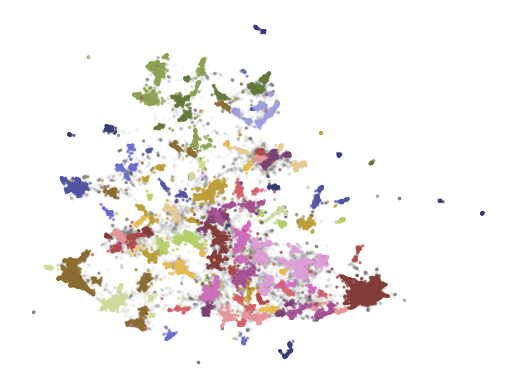

In [12]:
import matplotlib.pyplot as plt

# Plot outliers and non-outliers seperately
# 分别绘制 离群点 和 非离群点
# 解释：alpha 是透明度, s 是点的大小，cmap 是值颜色图
plt.scatter(outliers_df.x, outliers_df.y, alpha=0.05, s=2, c="grey")
plt.scatter(
    clusters_df.x, clusters_df.y, c=clusters_df.cluster.astype(int),
    alpha=0.6, s=2, cmap='tab20b'
)
plt.axis('off')
# plt.savefig("matplotlib.png", dpi=300)  # Uncomment to save the graph as a .png

# From Text Clustering to Topic Modeling
从文本聚类到主题建模

## **BERTopic: A Modular Topic Modeling Framework**
BERTopic ：一个模块化的主题建模框架

In [14]:
%%capture
!pip install bertopic

In [15]:
from bertopic import BERTopic

# Train our model with our previously defined models
# 定义我们的 BERTopic 模型，并训练
topic_model = BERTopic(
    embedding_model=embedding_model,  # 嵌入 embedding
    umap_model=umap_model,            # 降维
    hdbscan_model=hdbscan_model,      # 聚类
    verbose=True
).fit(abstracts, embeddings)          # 训练模型

2026-03-25 12:15:54,729 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-25 12:18:00,735 - BERTopic - Dimensionality - Completed ✓
2026-03-25 12:18:00,739 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-25 12:18:11,207 - BERTopic - Cluster - Completed ✓
2026-03-25 12:18:11,231 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-25 12:18:18,636 - BERTopic - Representation - Completed ✓


Now, let's start exploring the topics that we got by running the code above.
好了，现在让我们来探索一下通过上面代码运行后得到的主题

In [16]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,15483,-1_the_of_and_to,"[the, of, and, to, in, we, for, that, language...","[ Recent advances, such as GPT and BERT, have..."
1,0,2115,0_speech_asr_recognition_end,"[speech, asr, recognition, end, acoustic, spea...",[ We present a framework for building speech-...
2,1,1412,1_medical_clinical_biomedical_patient,"[medical, clinical, biomedical, patient, healt...",[ Background : Knowledge is evolving over tim...
3,2,910,2_summarization_summaries_summary_abstractive,"[summarization, summaries, summary, abstractiv...",[ Sentence summarization shortens given texts...
4,3,820,3_hate_offensive_speech_detection,"[hate, offensive, speech, detection, toxic, so...",[ Hate speech is a severe issue that affects ...
...,...,...,...,...,...
158,157,52,157_multimodal_sentiment_modality_fusion,"[multimodal, sentiment, modality, fusion, moda...",[ Multimodal machine learning is a core resea...
159,158,51,158_diffusion_generation_autoregressive_text,"[diffusion, generation, autoregressive, text, ...",[ Diffusion models have achieved great succes...
160,159,51,159_mixed_code_sentiment_mixing,"[mixed, code, sentiment, mixing, english, anal...",[ In today's interconnected and multilingual ...
161,160,50,160_rumor_rumors_rumour_rumours,"[rumor, rumors, rumour, rumours, stance, verac...",[ The rapid development of social media chang...


Hundreds of topics were generated using the default model! To get the top 10 keywords per topic as well as their c-TF-IDF weights, we can use the `get_topic()` function:

使用默认模型生成了数百个主题！要获取每个主题的前10个关键词以及它们的 c-TF-IDF 权重，我们可以使用`get_topic()`函数：
> TF-IDF 是词频-逆文档频率（Term Frequency-Inverse Document Frequency）的缩写，是一种用于评估词语在文档集合中的重要性的统计方法。
> c-TF-IDF 是类-词频-逆文档频率（Class-based TF-IDF）的缩写，是一种在主题建模中常用的加权方法，它考虑了文档类别对词语重要性的影响。

In [17]:
topic_model.get_topic(0)

[('speech', np.float64(0.028134416316413308)),
 ('asr', np.float64(0.01877611906252948)),
 ('recognition', np.float64(0.013364329221784637)),
 ('end', np.float64(0.010131669482210717)),
 ('acoustic', np.float64(0.009664586685077444)),
 ('speaker', np.float64(0.0068469586299213315)),
 ('audio', np.float64(0.006771109703879735)),
 ('error', np.float64(0.006466686534367473)),
 ('wer', np.float64(0.006398112986221887)),
 ('the', np.float64(0.006088686577824309))]

We can use the `find_topics()` function to search for specific topics based on a search term. Let’s search for a topic about topic modeling:  

我们可以使用`find_topics()`函数基于搜索词来查找特定主题。让我们搜索一个关于主题建模的主题：

In [18]:
topic_model.find_topics("topic modeling")

([21, -1, 1, 54, 35],
 [np.float64(0.9544375243454871),
  np.float64(0.9121192533926233),
  np.float64(0.9075419448649207),
  np.float64(0.9063320763006899),
  np.float64(0.9051119503461807)])

It returns that topic 21 has a relatively high similarity (0.95) with our search term. If we then inspect the topic, we can see that it is indeed a topic about topic modeling:
结果显示主题 21 与我们的搜索词有较高的相似度（0.95）。如果我们进一步检查这个主题，我们可以看到它确实是一个关于主题建模的主题：

In [19]:
topic_model.get_topic(21)

[('topic', np.float64(0.06674158962110557)),
 ('topics', np.float64(0.03512454989258186)),
 ('lda', np.float64(0.016482197059659573)),
 ('documents', np.float64(0.013209871016493973)),
 ('document', np.float64(0.013202876531992064)),
 ('latent', np.float64(0.013033915610160022)),
 ('modeling', np.float64(0.01184949262147989)),
 ('dirichlet', np.float64(0.009771587231972698)),
 ('word', np.float64(0.008389926887478881)),
 ('clustering', np.float64(0.007851526202224809))]

That seems like a topic that is, in part, characterized by the classic LDA technique. Let's see if the BERTopic paper was also assigned to topic 21:

这其实就是经典 LDA 技术所特征化的主题。让我们看看 BERTopic 论文是否也被分配到了主题 21

In [20]:
topic_model.topics_[titles.index('BERTopic: Neural topic modeling with a class-based TF-IDF procedure')]

21

It is! We expected it might be because there are non-LDA specific words in the topic describtion such as "clustering" and "topic".

### **Visualizations**
可视化

**Visualize Documents**

文档的可视化

In [21]:
# Visualize topics and documents
fig = topic_model.visualize_documents(
    titles,
    reduced_embeddings=reduced_embeddings,
    width=1200,
    hide_annotations=True
)

# Update fonts of legend for easier visualization
fig.update_layout(font=dict(size=16))

In [24]:
# Visualize barchart with ranked keywords
# 可视化带有排名关键词的条形图
topic_model.visualize_barchart()


In [25]:
# Visualize relationships between topics
# 可视化主题之间的关系
topic_model.visualize_heatmap(n_clusters=30)

In [26]:
# Visualize the potential hierarchical structure of topics
# 可视化主题的潜在层次结构
topic_model.visualize_hierarchy()

越上层，主题越抽象，越下层，主题越具体，两个进行连线的时候表示两者是相似的

## **Representation Models**
## 5.4 表示模型


In these examples that follow, we will update our topic representations **after** having trained our model. This allows for quick iteration. If, however, you want to use a representation model at the start of training, you will need to run it as follows:

在接下来的这些示例中，我们将在训练模型之后更新我们的主题表示。如果想在训练开始时使用表示模型，我们按以下方式运行它：


```python
from bertopic.representation import KeyBERTInspired
from bertopic import BERTopic

# Create your representation model
# 创建表示模型
representation_model = KeyBERTInspired()

# Use the representation model in BERTopic on top of the default pipeline
# 在 BERTopic 中使用这个表示模型
topic_model = BERTopic(representation_model=representation_model)
```

To use the representation models, we are first going to duplicate our topic model such that easily show the differences between a model with and without representation model.   
为了使用表示模型，我们首先要复制我们的主题模型，这样可以方便地展示有表示模型和没有表示模型的模型之间的差异。

In [27]:
# Save original representations
# 保存一下原始的 representations
from copy import deepcopy
original_topics = deepcopy(topic_model.topic_representations_)

In [29]:
def topic_differences(model, original_topics, nr_topics=5):
    """Show the differences in topic representations between two models """
    """显示两个模型之间主题表示的差异"""
    df = pd.DataFrame(columns=["Topic", "Original", "Updated"])
    for topic in range(nr_topics):

        # Extract top 5 words per topic per model
        # 提取每个模型每个主题的前 5 个关键词
        og_words = " | ".join(list(zip(*original_topics[topic]))[0][:5])
        new_words = " | ".join(list(zip(*model.get_topic(topic)))[0][:5])
        df.loc[len(df)] = [topic, og_words, new_words]

    return df

### KeyBERTInspired

In [30]:
from bertopic.representation import KeyBERTInspired

# Update our topic representations using KeyBERTInspired
# 将我们的主题表示为 KeyBERTInspired
representation_model = KeyBERTInspired()
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
# 展示主题表示的差异
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,phonetic | language | translation | speech | s...
1,1,medical | clinical | biomedical | patient | he...,ehr | nlp | clinical | ehrs | concepts
2,2,summarization | summaries | summary | abstract...,summarization | summarizers | summaries | summ...
3,3,hate | offensive | speech | detection | toxic,hate | hateful | language | languages | cyberb...
4,4,relation | extraction | relations | re | entity,relation | relations | relational | extracting...


### Maximal Marginal Relevance

In [31]:
from bertopic.representation import MaximalMarginalRelevance

# Update our topic representations to MaximalMarginalRelevance
# 更新我们的主题表示为 KeyBERTInspired
representation_model = MaximalMarginalRelevance(diversity=0.5)
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
# 展示主题差异
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,speech | asr | error | model | automatic
1,1,medical | clinical | biomedical | patient | he...,clinical | biomedical | patient | healthcare |...
2,2,summarization | summaries | summary | abstract...,summarization | document | extractive | rouge ...
3,3,hate | offensive | speech | detection | toxic,hate | speech | toxic | social | abusive
4,4,relation | extraction | relations | re | entity,extraction | relations | entity | distant | su...


KeyBERTInspired 和 Maximal Marginal Relevance 的区别

KeyBERTInspired:
- 基于 KeyBERT 算法，使用 BERT 嵌入来提取关键词
- 通过计算词嵌入和文档嵌入之间的余弦相似度来选择最相关的词
- 倾向于选择语义上最相关的词，可能会导致一些重复

Maximal Marginal Relevance (MMR):
- 在相关性和多样性之间取得平衡
- 通过迭代选择既相关又不同于已选词的词
- 可以通过调整 diversity 参数来控制多样性程度
- 有助于生成更多样化的主题表示，避免重复

主要区别:
- KeyBERTInspired 专注于相关性，MMR 在相关性和多样性之间平衡
- MMR 可以产生更多样化的结果，而 KeyBERTInspired 可能更专注但有重复
- MMR 有一个可调节的多样性参数，KeyBERTInspired 没有这种直接控制


## Text Generation

使用 生成式模型 做文本（文档）聚类


### Flan-T5

In [33]:
from transformers import pipeline
from bertopic.representation import TextGeneration

prompt = """I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: '[KEYWORDS]'.

Based on the documents and keywords, what is this topic about?"""

# bertopic 会默认替换到 [DOCUMENTS] 和 [KEYWORDS]
# 初始文档表示：BERTopic 首先使用预训练的语言模型（如 BERT、RoBERTa 等）将文档转换为向量表示。这一步不需要任何预定义的主题或关键词。

# Update our topic representations using Flan-T5
# 更新 topic representations 到使用 Flan-T5
generator = pipeline(
    # 'text2text-generation',
    'text-generation',
    model='google/flan-t5-small'
)
representation_model = TextGeneration(
    generator, prompt=prompt, doc_length=50, tokenizer="whitespace"
)
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
# 展示差别
topic_differences(topic_model, original_topics)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLl

,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,| | | |
1,1,medical | clinical | biomedical | patient | he...,| | | |
2,2,summarization | summaries | summary | abstract...,| | | |
3,3,hate | offensive | speech | detection | toxic,| | | |
4,4,relation | extraction | relations | re | entity,| | | |


### OpenAI

In [44]:
import openai
from bertopic.representation import OpenAI

prompt = """
I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: [KEYWORDS]

Based on the information above, extract a short topic label in the following format:
topic: <short topic label>
"""

from google.colab import userdata
DASHSCOPE_API_KEY = userdata.get("DASHSCOPE_API_KEY")
DASHSCOPE_API_BASE_URL_openai = "https://dashscope.aliyuncs.com/compatible-mode/v1"

from openai import OpenAI

# Update our topic representations using GPT-3.5
#client = openai.OpenAI(api_key="YOUR_KEY_HERE")
client = OpenAI(
    api_key=DASHSCOPE_API_KEY,
    base_url=DASHSCOPE_API_BASE_URL_openai
)

#representation_model = OpenAI(
#    client,
    #model="gpt-3.5-turbo",
    #exponential_backoff=True,
    #chat=True,
    #prompt=prompt
#)
topic_model.update_topics(
    abstracts,
    #representation_model=representation_model
    client
)

# Show topic differences
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,speech | asr | recognition | end | acoustic,speech | asr | recognition | end | acoustic
1,1,medical | clinical | biomedical | patient | he...,medical | clinical | biomedical | patient | he...
2,2,summarization | summaries | summary | abstract...,summarization | summaries | summary | abstract...
3,3,hate | offensive | speech | detection | toxic,hate | offensive | speech | detection | toxic
4,4,relation | extraction | relations | re | entity,relation | extraction | relations | re | entity


In [56]:
# Visualize topics and documents
fig = topic_model.visualize_document_datamap(
    titles,
    topics=list(range(20)),
    reduced_embeddings=reduced_embeddings,
    width=1200,
    #label_font_size=11,
    #label_wrap_width=20,
    #use_medoids=True,
)
plt.savefig("datamapplot.png", dpi=300)

NameError: name 'datamapplot' is not defined


## **BONUS**: Word Cloud

Make sure to pip install `wordcloud` first in order to follow this bonus:


First, we need to make sure that each topic is described by a bit more words than just 10 as that would make for a much more interesting wordcloud.

In [55]:
topic_model.update_topics(abstracts, top_n_words=500)

2026-03-25 13:09:22,229 - BERTopic - WARNING: Note that extracting more than 100 words from a sparse can slow down computation quite a bit.


Then, we can run the following code to generate the wordcloud for our topic modeling topic:

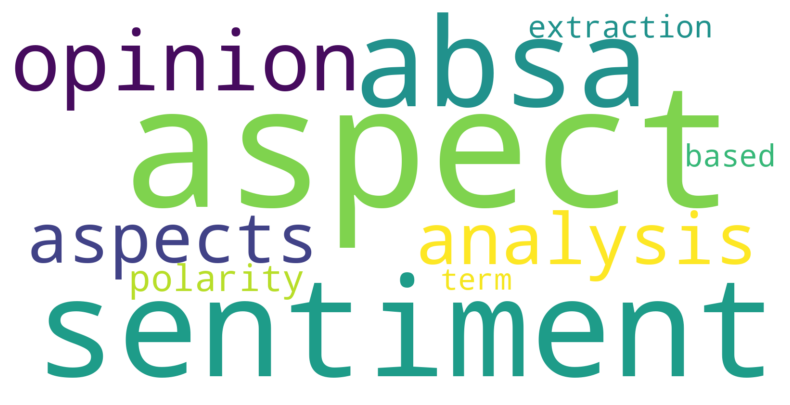

In [54]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def create_wordcloud(model, topic):
    plt.figure(figsize=(10,5))
    text = {word: value for word, value in model.get_topic(topic)}
    wc = WordCloud(background_color="white", max_words=1000, width=1600, height=800)
    wc.generate_from_frequencies(text)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

# Show wordcloud
create_wordcloud(topic_model, topic=17)